In [2]:
import pandas as pd

# specify columns to read
df = pd.read_csv("eval_returns\eval_returns_four_room_gpi-pd_weight_0.0_1.0_1777885103.csv", usecols=["avg_vec_return_0", "avg_vec_return_1", "avg_vec_return_2", "avg_vec_return_3"])

<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
C:\Users\skakr\AppData\Local\Temp\ipykernel_8096\943432347.py:4: SyntaxWarning: invalid escape sequence '\e'
  df = pd.read_csv("eval_returns\eval_returns_four_room_gpi-pd_weight_0.0_1.0_1777885103.csv", usecols=["avg_vec_return_0", "avg_vec_return_1", "avg_vec_return_2", "avg_vec_return_3"])
C:\Users\skakr\AppData\Local\Temp\ipykernel_8096\943432347.py:4: SyntaxWarning: invalid escape sequence '\e'
  df = pd.read_csv("eval_returns\eval_returns_four_room_gpi-pd_weight_0.0_1.0_1777885103.csv", usecols=["avg_vec_return_0", "avg_vec_return_1", "avg_vec_return_2", "avg_vec_return_3"])


FileNotFoundError: [Errno 2] No such file or directory: 'eval_returns\\eval_returns_four_room_gpi-pd_weight_0.0_1.0_1777885103.csv'

<Axes: xlabel='avg_vec_return_1', ylabel='avg_vec_return_3'>

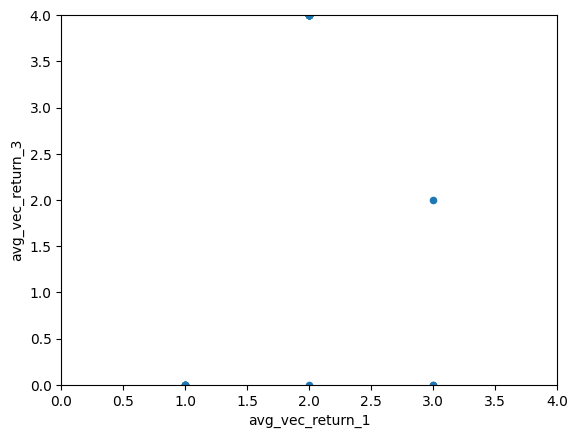

In [8]:
df.plot(kind='scatter', x='avg_vec_return_1', y='avg_vec_return_3', xlim=(0, 4), ylim=(0, 4))

In [ ]:
# pproximate Pareto front from a trained GPIPD/GPILS agent
from morl_baselines.common.evaluation import policy_evaluation_mo
from morl_baselines.common.weights import equally_spaced_weights
from morl_baselines.common.pareto import filter_pareto_dominated
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

N_WEIGHTS = 25
N_EPISODES_PER_WEIGHT = 5

returns = df.values

# Keep only non-dominated points (Pareto front approximation)
pareto_front = np.array(list(filter_pareto_dominated(returns)), dtype=np.float32)

print(f"Collected points: {len(returns)}")
print(f"Non-dominated points: {len(pareto_front)}")
print("Pareto front shape:", pareto_front.shape)

# Sort for cleaner plotting in 2D
if pareto_front.shape[1] == 2:
    pareto_front = pareto_front[np.argsort(pareto_front[:, 0])]

# Plot
if pareto_front.shape[1] == 2:
    plt.figure(figsize=(6, 5))
    plt.scatter(returns[:, 0], returns[:, 1], s=12, alpha=0.25, label="all eval points")
    plt.plot(pareto_front[:, 0], pareto_front[:, 1], "o-", color="black", label="pareto front")
    plt.xlabel("blue_triangle")
    plt.ylabel("red_triangle")
    plt.title("Approximated Pareto Front")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()
elif pareto_front.shape[1] == 3:
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(pareto_front[:, 0], pareto_front[:, 1], pareto_front[:, 2], s=20)
    ax.set_xlabel("objective_1")
    ax.set_ylabel("objective_2")
    ax.set_zlabel("objective_3")
    ax.set_title("Approximated Pareto Front")
    plt.show()
else:
    for i in range()

# Optional: save to CSV
# front_df = pd.DataFrame(pareto_front, columns=[f"objective_{i+1}" for i in range(pareto_front.shape[1])])
# front_df.to_csv("run_code/gpipd_pareto_front.csv", index=False)
# front_df.head()

Collected points: 25
Non-dominated points: 2
Pareto front shape: (2, 4)
Front has 4 objectives; skipping plot.


In [14]:
# Multi-policy returns visualization
# Loads all eval CSV files (one per training weight) and plots:
#   Plot 1 – Blue vs Red axes:      x = blue_triangle + blue_circle,  y = red_triangle + red_circle
#   Plot 2 – Circle vs Triangle axes: x = blue_circle + red_circle,  y = blue_triangle + red_triangle
#
# Marker shape encodes the training weight:
#   weight 0.0_1.0  (pure circle)   -> circle  'o'
#   weight 1.0_0.0  (pure triangle) -> triangle '^'
#   weights in between              -> intermediate markers
#
# Objective indices in the CSV:
#   avg_vec_return_0 = blue_triangle
#   avg_vec_return_1 = blue_circle
#   avg_vec_return_2 = red_triangle
#   avg_vec_return_3 = red_circle

import glob
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------

def parse_training_weight(filename):
    """Return (triangle_weight, circle_weight) extracted from the filename."""
    base = os.path.basename(filename)
    match = re.search(r'weight_(\d+(?:\.\d+)?)_(\d+(?:\.\d+)?)', base)
    if match:
        return float(match.group(1)), float(match.group(2))
    raise ValueError(f"Filename does not match expected pattern: {filename}")

# Markers ordered from circle-like to triangle-like as triangle_weight increases
_MARKER_SEQUENCE = ['o', 'p', 'D', 's', '^']  # circle, square, diamond, pentagon, triangle

def weight_to_marker(triangle_weight, all_triangle_weights):
    """Map a triangle_weight value to a marker by rank among all weights."""
    sorted_weights = sorted(set(all_triangle_weights))
    n = len(sorted_weights)
    rank = sorted_weights.index(triangle_weight)
    # Map rank 0..(n-1) onto _MARKER_SEQUENCE
    if n == 1:
        return _MARKER_SEQUENCE[0]
    idx = round(rank / (n - 1) * (len(_MARKER_SEQUENCE) - 1))
    return _MARKER_SEQUENCE[idx]

# ---------------------------------------------------------------------------
# Load all CSV files
# ---------------------------------------------------------------------------

csv_pattern = os.path.join('results/data/gpi-pd_four_room_data', 'eval_returns_my-four-room-*.csv')
csv_files = sorted(glob.glob(csv_pattern))

# if not csv_files:
#     # Fallback: notebook is run from inside eval_returns/
#     csv_files = sorted(glob.glob('eval_returns_my-four-room*.csv'))

print(f'Found {len(csv_files)} CSV file(s):')
for f in csv_files:
    print(f'  {os.path.basename(f)}')

datasets = []
for filepath in csv_files:
    tw, cw = parse_training_weight(filepath)
    df_file = pd.read_csv(filepath)
    datasets.append({'df': df_file, 'triangle_weight': tw, 'circle_weight': cw})

# Sort by triangle_weight ascending (pure-circle first, pure-triangle last)
datasets.sort(key=lambda d: d['triangle_weight'])

all_tw = [d['triangle_weight'] for d in datasets]
for d in datasets:
    d['marker'] = weight_to_marker(d['triangle_weight'], all_tw)
    d['label'] = f"w=({d['triangle_weight']:.2f}\u25b3, {d['circle_weight']:.2f}\u25cb)"

print('\nDataset summary:')
for d in datasets:
    print(f"  {d['label']}  marker='{d['marker']}'  rows={len(d['df'])}")

Found 5 CSV file(s):
  eval_returns_my-four-room-v0__GPI-PD_weight_0.00_1.00__42__1777885103.csv
  eval_returns_my-four-room-v0__GPI-PD_weight_0.25_0.75__42__1777890878.csv
  eval_returns_my-four-room-v0__GPI-PD_weight_0.50_0.50__42__1777895969.csv
  eval_returns_my-four-room-v0__GPI-PD_weight_0.75_0.25__42__1777902980.csv
  eval_returns_my-four-room-v0__GPI-PD_weight_1.00_0.00__42__1777910770.csv

Dataset summary:
  w=(0.00△, 1.00○)  marker='o'  rows=25
  w=(0.25△, 0.75○)  marker='p'  rows=25
  w=(0.50△, 0.50○)  marker='D'  rows=25
  w=(0.75△, 0.25○)  marker='s'  rows=25
  w=(1.00△, 0.00○)  marker='^'  rows=25


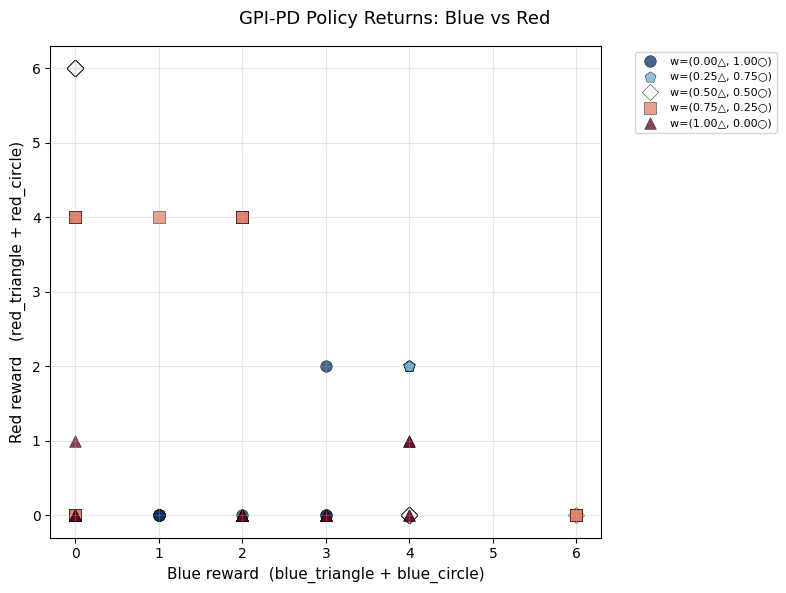

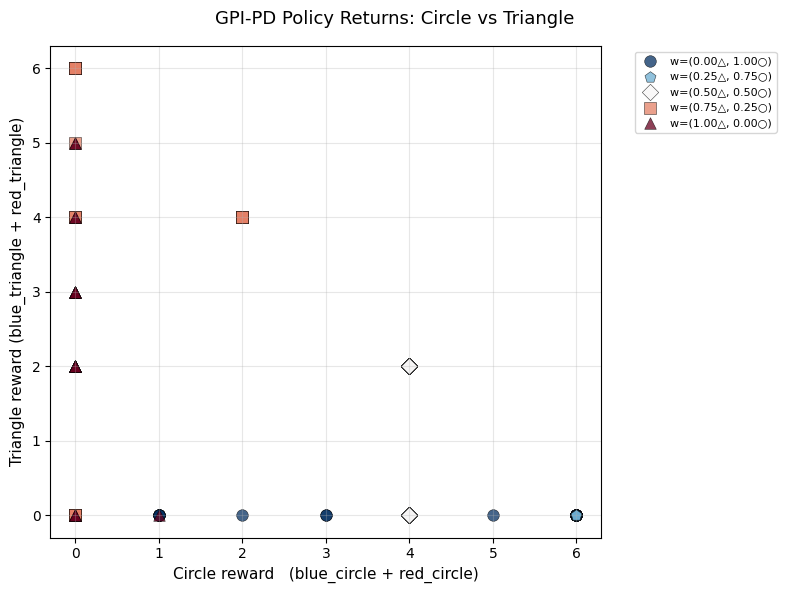

In [16]:
# ---------------------------------------------------------------------------
# Two scatter plots: Blue/Red axes  and  Circle/Triangle axes (Separate figures)
# ---------------------------------------------------------------------------

# Color gradient: blue (pure-circle policy) -> red (pure-triangle policy)
cmap = plt.cm.RdBu_r
n = len(datasets)
colors = [cmap(i / max(n - 1, 1)) for i in range(n)]

fig1, ax1 = plt.subplots(figsize=(8, 6))
fig1.suptitle('GPI-PD Policy Returns: Blue vs Red', fontsize=13)

fig2, ax2 = plt.subplots(figsize=(8, 6))
fig2.suptitle('GPI-PD Policy Returns: Circle vs Triangle', fontsize=13)

for i, d in enumerate(datasets):
    df_d = d['df']
    marker = d['marker']
    label  = d['label']
    color  = colors[i]

    # --- Plot 1: Blue vs Red ---
    blue_reward     = df_d['avg_vec_return_0'] + df_d['avg_vec_return_1']  # blue_triangle + blue_circle
    red_reward      = df_d['avg_vec_return_2'] + df_d['avg_vec_return_3']  # red_triangle  + red_circle
    ax1.scatter(blue_reward, red_reward,
                    marker=marker, color=[color], label=label,
                    s=70, alpha=0.75, edgecolors='k', linewidths=0.4)

    # --- Plot 2: Circle vs Triangle ---
    circle_reward   = df_d['avg_vec_return_1'] + df_d['avg_vec_return_3']  # blue_circle   + red_circle
    triangle_reward = df_d['avg_vec_return_0'] + df_d['avg_vec_return_2']  # blue_triangle + red_triangle
    ax2.scatter(circle_reward, triangle_reward,
                    marker=marker, color=[color], label=label,
                    s=70, alpha=0.75, edgecolors='k', linewidths=0.4)

# --- Axis labels & styling ---
ax1.set_xlabel('Blue reward  (blue_triangle + blue_circle)', fontsize=11)
ax1.set_ylabel('Red reward   (red_triangle + red_circle)',   fontsize=11)
ax1.legend(fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Circle reward   (blue_circle + red_circle)',   fontsize=11)
ax2.set_ylabel('Triangle reward (blue_triangle + red_triangle)', fontsize=11)
ax2.legend(fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, alpha=0.3)

fig1.tight_layout()
fig1.savefig(os.path.join('results/figures', 'policy_returns_blue_red.png'),
            dpi=150, bbox_inches='tight')

fig2.tight_layout()
fig2.savefig(os.path.join('results/figures', 'policy_returns_circle_triangle.png'),
            dpi=150, bbox_inches='tight')

plt.show()

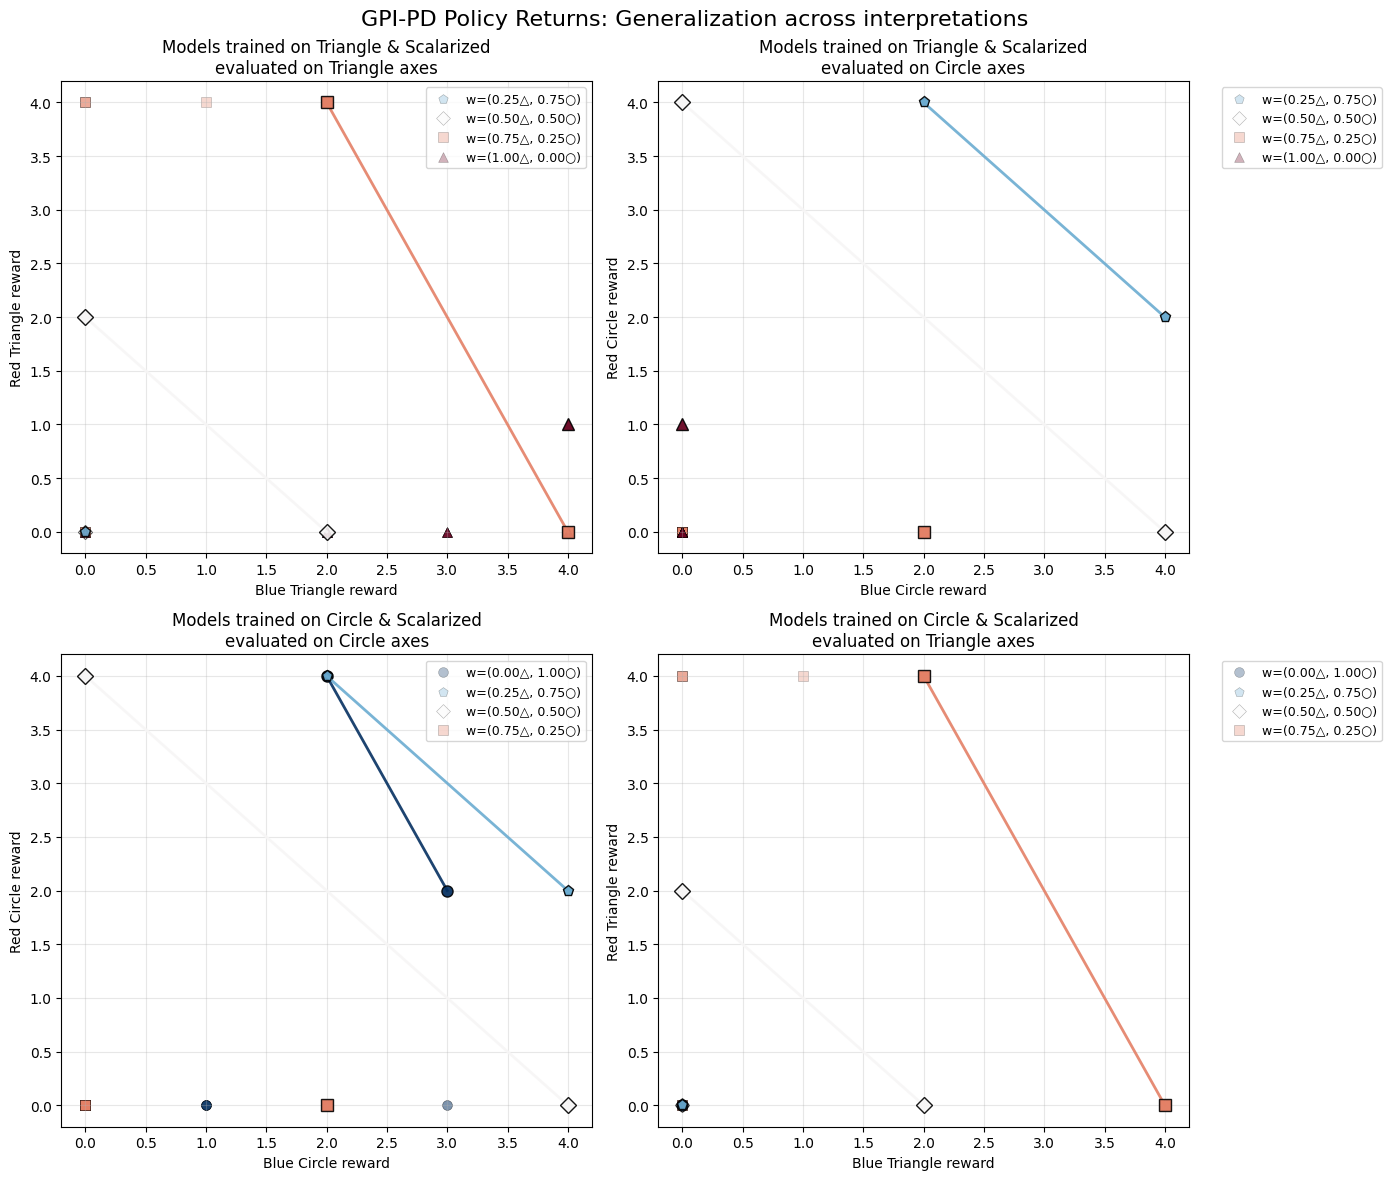

In [23]:
# ---------------------------------------------------------------------------
# Four scatter plots with connected Pareto fronts
# ---------------------------------------------------------------------------
from morl_baselines.common.pareto import filter_pareto_dominated

fig, axs = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('GPI-PD Policy Returns: Generalization across interpretations', fontsize=16)

def plot_with_pareto(ax, x_vals, y_vals, marker, color, label):
    # Scatter all points with lower opacity
    ax.scatter(x_vals, y_vals, marker=marker, color=[color], label=label,
               s=50, alpha=0.3, edgecolors='k', linewidths=0.4)
    
    # Calculate Pareto front for this model's evaluations
    points = np.column_stack((x_vals, y_vals))
    front_list = list(filter_pareto_dominated(points))
    if front_list:
        front = np.array(front_list, dtype=np.float32)
        # Sort by x for line plotting
        front = front[np.argsort(front[:, 0])]
        # Plot the pareto front dots and connect them
        ax.plot(front[:, 0], front[:, 1], marker=marker, color=color, alpha=0.9, linewidth=2, markersize=8, markeredgecolor='k')

for i, d in enumerate(datasets):
    df_d = d['df']
    marker = d['marker']
    label  = d['label']
    color  = colors[i]
    tw = d['triangle_weight']

    blue_triangle = df_d['avg_vec_return_0'].values
    red_triangle  = df_d['avg_vec_return_2'].values
    
    blue_circle = df_d['avg_vec_return_1'].values
    red_circle  = df_d['avg_vec_return_3'].values

    # --- Top Row: Models trained on Triangle and Scalarized (tw > 0.0) ---
    if tw > 0.0:
        # Top Left: evaluated on Triangle axes
        plot_with_pareto(axs[0, 0], blue_triangle, red_triangle, marker, color, label)
        # Top Right: evaluated on Circle axes
        plot_with_pareto(axs[0, 1], blue_circle, red_circle, marker, color, label)

    # --- Bottom Row: Models trained on Circle and Scalarized (tw < 1.0) ---
    if tw < 1.0:
        # Bottom Left: evaluated on Circle axes
        plot_with_pareto(axs[1, 0], blue_circle, red_circle, marker, color, label)
        # Bottom Right: evaluated on Triangle axes
        plot_with_pareto(axs[1, 1], blue_triangle, red_triangle, marker, color, label)

# --- Axis labels & styling ---
axs[0, 0].set_title('Models trained on Triangle & Scalarized\nevaluated on Triangle axes')
axs[0, 0].set_xlabel('Blue Triangle reward')
axs[0, 0].set_ylabel('Red Triangle reward')
axs[0, 0].set_xlim(-0.2, 4.2)
axs[0, 0].set_ylim(-0.2, 4.2)
axs[0, 0].legend(fontsize=9)
axs[0, 0].grid(True, alpha=0.3)

axs[0, 1].set_title('Models trained on Triangle & Scalarized\nevaluated on Circle axes')
axs[0, 1].set_xlabel('Blue Circle reward')
axs[0, 1].set_ylabel('Red Circle reward')
axs[0, 1].set_xlim(-0.2, 4.2)
axs[0, 1].set_ylim(-0.2, 4.2)
axs[0, 1].legend(fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')
axs[0, 1].grid(True, alpha=0.3)

axs[1, 0].set_title('Models trained on Circle & Scalarized\nevaluated on Circle axes')
axs[1, 0].set_xlabel('Blue Circle reward')
axs[1, 0].set_ylabel('Red Circle reward')
axs[1, 0].set_xlim(-0.2, 4.2)
axs[1, 0].set_ylim(-0.2, 4.2)
axs[1, 0].legend(fontsize=9)
axs[1, 0].grid(True, alpha=0.3)

axs[1, 1].set_title('Models trained on Circle & Scalarized\nevaluated on Triangle axes')
axs[1, 1].set_xlabel('Blue Triangle reward')
axs[1, 1].set_ylabel('Red Triangle reward')
axs[1, 1].set_xlim(-0.2, 4.2)
axs[1, 1].set_ylim(-0.2, 4.2)
axs[1, 1].legend(fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')
axs[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
# Adjust top margin so the suptitle doesn't overlap
plt.subplots_adjust(top=0.92)
plt.savefig(os.path.join('results/figures', 'policy_returns_generalization_4_plots.png'), dpi=150, bbox_inches='tight')

plt.show()

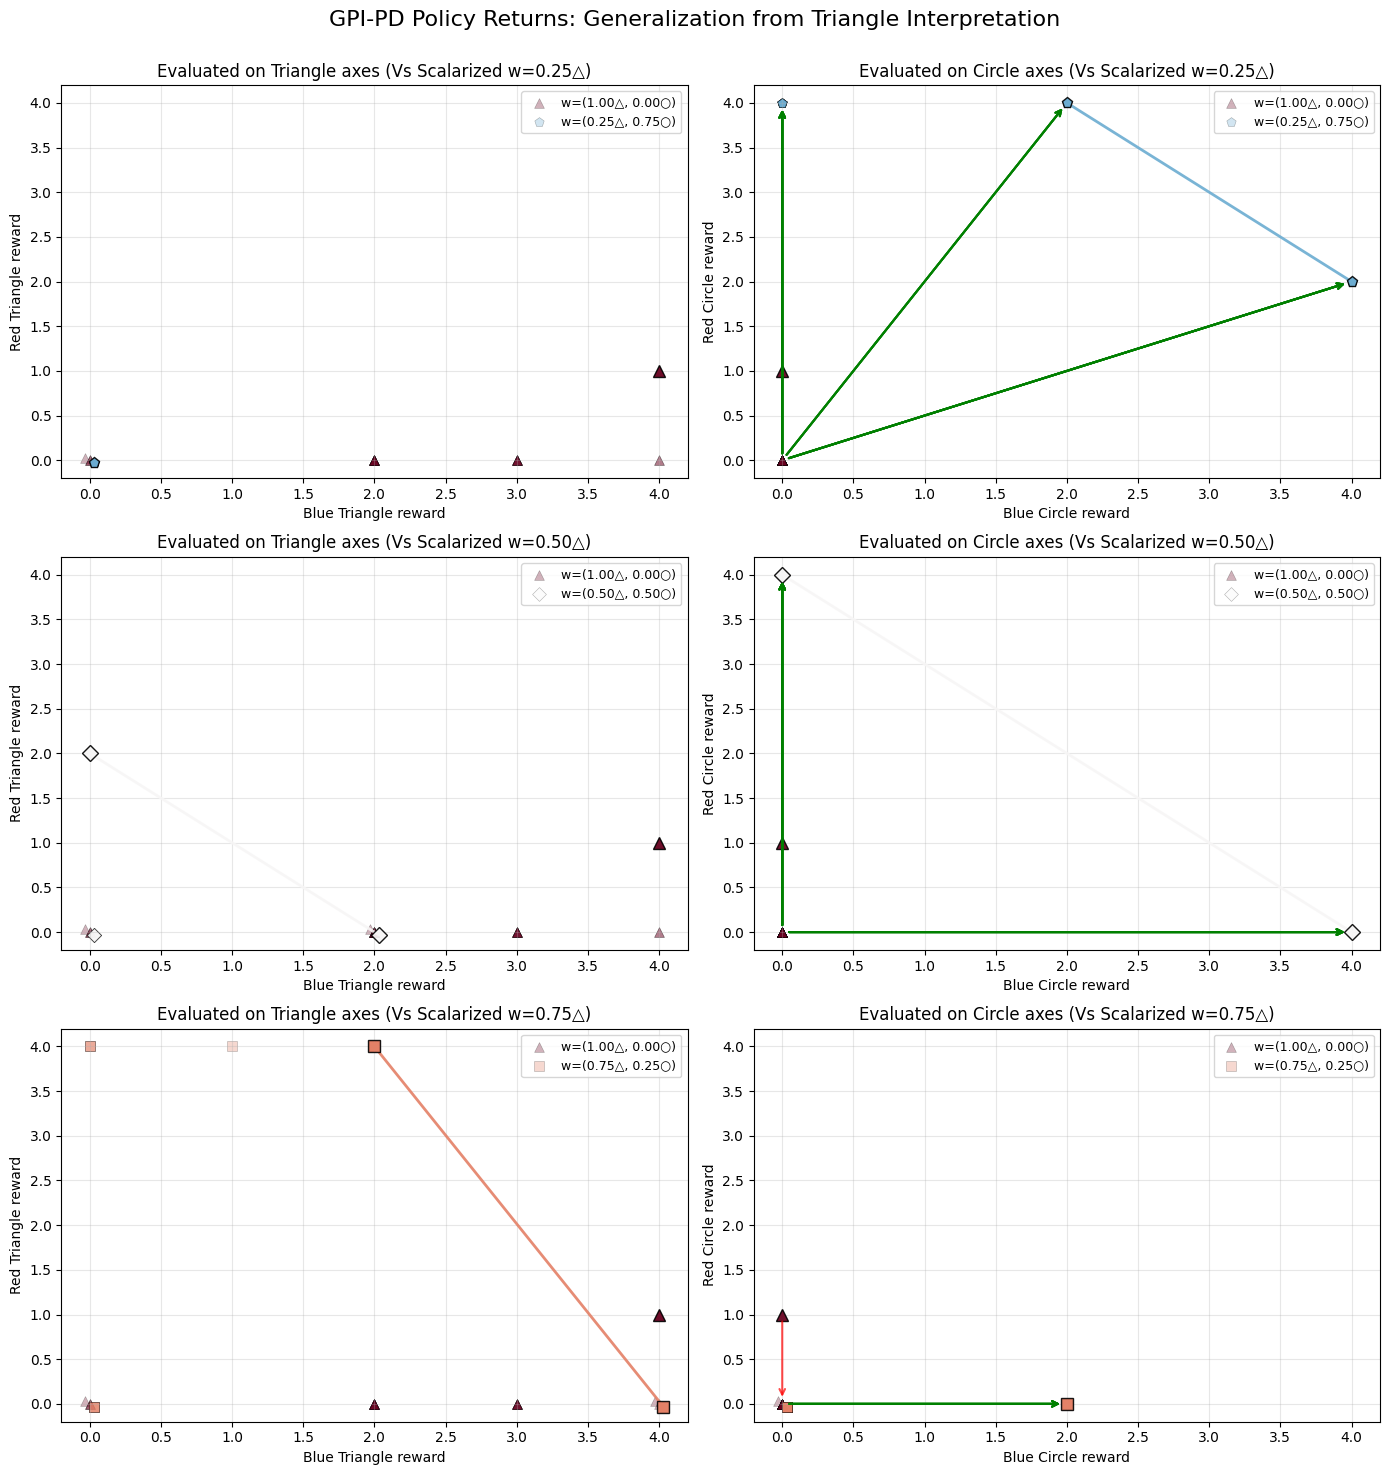

In [28]:
# ---------------------------------------------------------------------------
# Subplots comparing Pure Triangle (1.0) with each scalarized model
# ---------------------------------------------------------------------------
from morl_baselines.common.pareto import filter_pareto_dominated

def plot_with_pareto(ax, x_vals, y_vals, marker, color, label, x_shift=None, y_shift=None):
    if x_shift is None: x_shift = np.zeros_like(x_vals, dtype=np.float64)
    if y_shift is None: y_shift = np.zeros_like(y_vals, dtype=np.float64)
    
    x_plot = x_vals + x_shift
    y_plot = y_vals + y_shift
    
    # Scatter visually shifted points
    ax.scatter(x_plot, y_plot, marker=marker, color=[color], label=label,
               s=50, alpha=0.3, edgecolors='k', linewidths=0.4)
    
    # Calculate Pareto front for this model's evaluations
    points = np.column_stack((x_vals, y_vals))
    front_list = list(filter_pareto_dominated(points))
    if front_list:
        front = np.array(front_list, dtype=np.float32)
        # Sort by x for line plotting
        front = front[np.argsort(front[:, 0])]
        
        # Map to visually shifted coords
        front_x_plot, front_y_plot = [], []
        for fx, fy in front:
            for i in range(len(x_vals)):
                if abs(x_vals[i] - fx) < 1e-4 and abs(y_vals[i] - fy) < 1e-4:
                    front_x_plot.append(x_plot[i])
                    front_y_plot.append(y_plot[i])
                    break
        
        if len(front_x_plot) > 0:
            ax.plot(front_x_plot, front_y_plot, marker=marker, color=color, alpha=0.9, linewidth=2, markersize=8, markeredgecolor='k')

scalarized_indices = [i for i, d in enumerate(datasets) if 0.0 < d['triangle_weight'] < 1.0 and d['triangle_weight'] > 0.0]
pure_tri_idx = next((i for i, d in enumerate(datasets) if d['triangle_weight'] == 1.0), None)

n_rows = max(1, len(scalarized_indices))
fig, axs = plt.subplots(n_rows, 2, figsize=(14, 5 * n_rows))
fig.suptitle('GPI-PD Policy Returns: Generalization from Triangle Interpretation', fontsize=16)

# Make axs a 2D array even if n_rows=1
if n_rows == 1:
    axs = np.array([axs])

for row, sc_idx in enumerate(scalarized_indices):
    d_sc = datasets[sc_idx]
    
    # Left plot: Triangle Axes
    ax_tri = axs[row, 0]
    # Right plot: Circle Axes
    ax_cir = axs[row, 1]
    
    for ax, is_triangle_axes in [(ax_tri, True), (ax_cir, False)]:
        x_p, y_p = np.array([]), np.array([])
        
        # 1. Fetch pure triangle model data
        if pure_tri_idx is not None:
            d_pure = datasets[pure_tri_idx]
            df_pure = d_pure['df']
            x_p = df_pure['avg_vec_return_0'].values if is_triangle_axes else df_pure['avg_vec_return_1'].values
            y_p = df_pure['avg_vec_return_2'].values if is_triangle_axes else df_pure['avg_vec_return_3'].values
            
        # 2. Fetch specific scalarized model data
        df_sc = d_sc['df']
        x_s = df_sc['avg_vec_return_0'].values if is_triangle_axes else df_sc['avg_vec_return_1'].values
        y_s = df_sc['avg_vec_return_2'].values if is_triangle_axes else df_sc['avg_vec_return_3'].values
        
        # Compute visual shifts for overlapping points
        x_shift_p = np.zeros_like(x_p, dtype=np.float64)
        y_shift_p = np.zeros_like(y_p, dtype=np.float64)
        x_shift_s = np.zeros_like(x_s, dtype=np.float64)
        y_shift_s = np.zeros_like(y_s, dtype=np.float64)
        
        if len(x_p) > 0 and len(x_s) > 0:
            for j in range(len(x_s)):
                for k in range(len(x_p)):
                    if abs(x_s[j] - x_p[k]) < 1e-4 and abs(y_s[j] - y_p[k]) < 1e-4:
                        x_shift_p[k] = -0.03
                        y_shift_p[k] = 0.03
                        x_shift_s[j] = 0.03
                        y_shift_s[j] = -0.03
                        break
                        
        # Plot the models
        if pure_tri_idx is not None:
            plot_with_pareto(ax, x_p, y_p, d_pure['marker'], colors[pure_tri_idx], d_pure['label'], x_shift_p, y_shift_p)
            
        plot_with_pareto(ax, x_s, y_s, d_sc['marker'], colors[sc_idx], d_sc['label'], x_shift_s, y_shift_s)
        
        # 3. Draw colored arrows on the right side plot (evaluated on circle axes)
        if not is_triangle_axes and pure_tri_idx is not None:
            used_s_indices = set()
            for k in range(len(x_p)):
                p_coord = np.array([x_p[k], y_p[k]])
                min_dist = float('inf')
                best_j = -1
                for j in range(len(x_s)):
                    if j in used_s_indices:
                        continue
                    s_coord = np.array([x_s[j], y_s[j]])
                    dist = np.linalg.norm(p_coord - s_coord)
                    if dist < min_dist:
                        min_dist = dist
                        best_j = j
                if best_j != -1:
                    used_s_indices.add(best_j)
                    diff_x = x_s[best_j] - x_p[k]
                    diff_y = y_s[best_j] - y_p[k]
                    
                    # Green if Pareto-better (or equal), Red if Pareto-worse (or equal), else Gray
                    if diff_x >= -1e-4 and diff_y >= -1e-4:
                        arrow_col = 'green'
                    elif diff_x <= 1e-4 and diff_y <= 1e-4:
                        arrow_col = 'red'
                    else:
                        arrow_col = 'gray'
                        
                    # Draw arrow from original exact pure point to original exact scalarized point
                    ax.annotate('', xy=(x_s[best_j], y_s[best_j]), xytext=(x_p[k], y_p[k]),
                                arrowprops=dict(arrowstyle='->', color=arrow_col, alpha=0.7, shrinkA=5, shrinkB=5, linewidth=1.5))

        # Formatting
        if is_triangle_axes:
            ax.set_title(f'Evaluated on Triangle axes (Vs Scalarized w={d_sc["triangle_weight"]:.2f}\u25b3)')
            ax.set_xlabel('Blue Triangle reward')
            ax.set_ylabel('Red Triangle reward')
        else:
            ax.set_title(f'Evaluated on Circle axes (Vs Scalarized w={d_sc["triangle_weight"]:.2f}\u25b3)')
            ax.set_xlabel('Blue Circle reward')
            ax.set_ylabel('Red Circle reward')
            
        ax.set_xlim(-0.2, 4.2)
        ax.set_ylim(-0.2, 4.2)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
# Adjust top margin so the suptitle doesn't overlap
plt.subplots_adjust(top=0.96 - (0.01 * n_rows))
plt.savefig(os.path.join('results/figures', 'policy_returns_pure_vs_scalarized.png'), dpi=150, bbox_inches='tight')

plt.show()

In [ ]:
# ---------------------------------------------------------------------------
# Subplots comparing Pure Circle (0.0 triangle) with each scalarized model
# ---------------------------------------------------------------------------
from morl_baselines.common.pareto import filter_pareto_dominated

def plot_with_pareto(ax, x_vals, y_vals, marker, color, label, x_shift=None, y_shift=None):
    if x_shift is None: x_shift = np.zeros_like(x_vals, dtype=np.float64)
    if y_shift is None: y_shift = np.zeros_like(y_vals, dtype=np.float64)
    
    x_plot = x_vals + x_shift
    y_plot = y_vals + y_shift
    
    # Scatter visually shifted points
    ax.scatter(x_plot, y_plot, marker=marker, color=[color], label=label,
               s=50, alpha=0.3, edgecolors='k', linewidths=0.4)
    
    # Calculate Pareto front for this model's evaluations
    points = np.column_stack((x_vals, y_vals))
    front_list = list(filter_pareto_dominated(points))
    if front_list:
        front = np.array(front_list, dtype=np.float32)
        # Sort by x for line plotting
        front = front[np.argsort(front[:, 0])]
        
        # Map to visually shifted coords
        front_x_plot, front_y_plot = [], []
        for fx, fy in front:
            for i in range(len(x_vals)):
                if abs(x_vals[i] - fx) < 1e-4 and abs(y_vals[i] - fy) < 1e-4:
                    front_x_plot.append(x_plot[i])
                    front_y_plot.append(y_plot[i])
                    break
                    
        if len(front_x_plot) > 0:
            ax.plot(front_x_plot, front_y_plot, marker=marker, color=color, alpha=0.9, linewidth=2, markersize=8, markeredgecolor='k')

scalarized_indices = [i for i, d in enumerate(datasets) if 0.0 < d['triangle_weight'] < 1.0]
pure_cir_idx = next((i for i, d in enumerate(datasets) if d['triangle_weight'] == 0.0), None)

n_rows = max(1, len(scalarized_indices))
fig, axs = plt.subplots(n_rows, 2, figsize=(14, 5 * n_rows))
fig.suptitle('GPI-PD Policy Returns: Generalization from Circle Interpretation', fontsize=16)

# Make axs a 2D array even if n_rows=1
if n_rows == 1:
    axs = np.array([axs])

for row, sc_idx in enumerate(scalarized_indices):
    d_sc = datasets[sc_idx]
    
    # Left plot: Circle Axes
    ax_cir = axs[row, 0]
    # Right plot: Triangle Axes
    ax_tri = axs[row, 1]
    
    for ax, is_circle_axes in [(ax_cir, True), (ax_tri, False)]:
        x_p, y_p = np.array([]), np.array([])
        
        # 1. Fetch pure circle model data
        if pure_cir_idx is not None:
            d_pure = datasets[pure_cir_idx]
            df_pure = d_pure['df']
            x_p = df_pure['avg_vec_return_1'].values if is_circle_axes else df_pure['avg_vec_return_0'].values
            y_p = df_pure['avg_vec_return_3'].values if is_circle_axes else df_pure['avg_vec_return_2'].values
            
        # 2. Fetch specific scalarized model data
        df_sc = d_sc['df']
        x_s = df_sc['avg_vec_return_1'].values if is_circle_axes else df_sc['avg_vec_return_0'].values
        y_s = df_sc['avg_vec_return_3'].values if is_circle_axes else df_sc['avg_vec_return_2'].values
        
        # Compute visual shifts for overlapping points
        x_shift_p = np.zeros_like(x_p, dtype=np.float64)
        y_shift_p = np.zeros_like(y_p, dtype=np.float64)
        x_shift_s = np.zeros_like(x_s, dtype=np.float64)
        y_shift_s = np.zeros_like(y_s, dtype=np.float64)
        
        if len(x_p) > 0 and len(x_s) > 0:
            for j in range(len(x_s)):
                for k in range(len(x_p)):
                    if abs(x_s[j] - x_p[k]) < 1e-4 and abs(y_s[j] - y_p[k]) < 1e-4:
                        x_shift_p[k] = -0.03
                        y_shift_p[k] = 0.03
                        x_shift_s[j] = 0.03
                        y_shift_s[j] = -0.03
                        break
                        
        # Plot the models
        if pure_cir_idx is not None:
            plot_with_pareto(ax, x_p, y_p, d_pure['marker'], colors[pure_cir_idx], d_pure['label'], x_shift_p, y_shift_p)
            
        plot_with_pareto(ax, x_s, y_s, d_sc['marker'], colors[sc_idx], d_sc['label'], x_shift_s, y_shift_s)
        
        # 3. Draw colored arrows on the right side plot (evaluated on triangle axes)
        if not is_circle_axes and pure_cir_idx is not None:
            used_s_indices = set()
            for k in range(len(x_p)):
                p_coord = np.array([x_p[k], y_p[k]])
                min_dist = float('inf')
                best_j = -1
                for j in range(len(x_s)):
                    if j in used_s_indices:
                        continue
                    s_coord = np.array([x_s[j], y_s[j]])
                    dist = np.linalg.norm(p_coord - s_coord)
                    if dist < min_dist:
                        min_dist = dist
                        best_j = j
                if best_j != -1:
                    used_s_indices.add(best_j)
                    diff_x = x_s[best_j] - x_p[k]
                    diff_y = y_s[best_j] - y_p[k]
                    
                    # Green if Pareto-better (or equal), Red if Pareto-worse (or equal), else Gray
                    if diff_x >= -1e-4 and diff_y >= -1e-4:
                        arrow_col = 'green'
                    elif diff_x <= 1e-4 and diff_y <= 1e-4:
                        arrow_col = 'red'
                    else:
                        arrow_col = 'gray'
                        
                    # Draw arrow from original exact pure point to original exact scalarized point
                    ax.annotate('', xy=(x_s[best_j], y_s[best_j]), xytext=(x_p[k], y_p[k]),
                                arrowprops=dict(arrowstyle='->', color=arrow_col, alpha=0.7, shrinkA=5, shrinkB=5, linewidth=1.5))
        
        # Formatting
        if is_circle_axes:
            ax.set_title(f'Evaluated on Circle axes (Vs Scalarized w={d_sc["triangle_weight"]:.2f}\u25b3)')
            ax.set_xlabel('Blue Circle reward')
            ax.set_ylabel('Red Circle reward')
        else:
            ax.set_title(f'Evaluated on Triangle axes (Vs Scalarized w={d_sc["triangle_weight"]:.2f}\u25b3)')
            ax.set_xlabel('Blue Triangle reward')
            ax.set_ylabel('Red Triangle reward')
            
        ax.set_xlim(-0.2, 4.2)
        ax.set_ylim(-0.2, 4.2)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
# Adjust top margin so the suptitle doesn't overlap
plt.subplots_adjust(top=0.96 - (0.01 * n_rows))
plt.savefig(os.path.join('results/figures', 'policy_returns_pure_circle_vs_scalarized.png'), dpi=150, bbox_inches='tight')

plt.show()

In [2]:
import wandb
import os
import json
import pandas as pd
from datetime import datetime, timedelta

def download_policy_returns(entity, project):
    # Initialize wandb API
    api = wandb.Api()
    
    # Calculate the timestamp for 2 days ago
    two_days_ago = datetime.now() - timedelta(days=2)
    
    # Fetch runs created in the last 2 days
    runs = api.runs(
        f"{entity}/{project}", 
        filters={"created_at": {"$gte": two_days_ago.isoformat()}}
    )
    
    # Ensure the output directory exists
    output_dir = "/eval_returns"
    os.makedirs(output_dir, exist_ok=True)
    
    print(f"Found {len(runs)} runs from the past 2 days. Searching for 'policy_returns' tables...")
    
    for run in runs:
        try:
            # W&B Tables are saved as artifacts of type 'run_table'
            for artifact in run.logged_artifacts():
                if artifact.type == "run_table" and "policy_returns" in artifact.name:
                    print(f"Found table in run: {run.name}")
                    
                    # Download the artifact
                    artifact_dir = artifact.download()
                    
                    # The artifact contains a .table.json file with the columns and data
                    for file_name in os.listdir(artifact_dir):
                        if file_name.endswith('.table.json'):
                            file_path = os.path.join(artifact_dir, file_name)
                            
                            with open(file_path, 'r') as f:
                                table_data = json.load(f)
                            
                            # Convert the W&B table JSON into a pandas DataFrame
                            df = pd.DataFrame(
                                data=table_data["data"], 
                                columns=table_data["columns"]
                            )
                            
                            # Save to the requested output format
                            output_path = os.path.join(output_dir, f"eval_returns_{run.name}.csv")
                            df.to_csv(output_path, index=False)
                            print(f"Saved: {output_path}")
                            
        except Exception as e:
            print(f"Error processing run {run.name}: {e}")

# Replace with your W&B entity (username or team name) and project name
ENTITY = "kristofs-ai"
PROJECT = "MORL-Baselines"

download_policy_returns(ENTITY, PROJECT)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


Found 9 runs from the past 2 days. Searching for 'policy_returns' tables...
Found table in run: my-four-room-v0__GPI-PD_weight_0.00_1.00__42__1777885103


wandb:   1 of 1 files downloaded.  


Saved: /eval_returns\eval_returns_my-four-room-v0__GPI-PD_weight_0.00_1.00__42__1777885103.csv
Found table in run: my-four-room-v0__GPI-PD_weight_0.25_0.75__42__1777890878


wandb:   1 of 1 files downloaded.  


...

Saved: /eval_returns\eval_returns_my-four-room-v0__GPI-PD_weight_0.50_0.50__42__1777895969.csv
Found table in run: my-four-room-v0__GPI-PD_weight_0.75_0.25__42__1777902980


wandb:   1 of 1 files downloaded.  


Saved: /eval_returns\eval_returns_my-four-room-v0__GPI-PD_weight_0.75_0.25__42__1777902980.csv
Found table in run: my-four-room-v0__GPI-PD_weight_1.00_0.00__42__1777910770


wandb:   1 of 1 files downloaded.  


Saved: /eval_returns\eval_returns_my-four-room-v0__GPI-PD_weight_1.00_0.00__42__1777910770.csv
